In [2]:
!kaggle datasets download -d oddrationale/mnist-in-csv

!unzip -o mnist-in-csv.zip

print("\nDataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:00<00:00, 53.3MB/s]

Archive:  mnist-in-csv.zip
  inflating: mnist_test.csv          
  inflating: mnist_train.csv         

Dataset successfully downloaded and extracted!


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Input features: Pixel values
Target variable: The 'label' column containing the digit (0-9)

Dataset Dimensions: (60000, 785)

Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


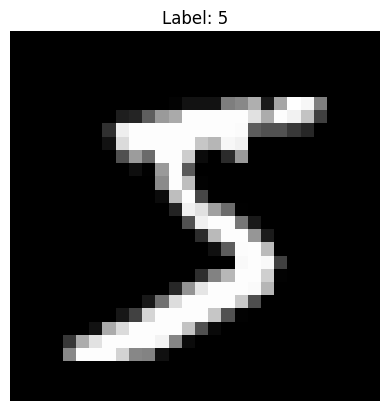

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('mnist_train.csv')

display(df.head())

print("Input features: Pixel values")
print("Target variable: The 'label' column containing the digit (0-9)")

print(f"\nDataset Dimensions: {df.shape}")
print("\nSummary Information:")
df.info()

sample_label = df.iloc[0, 0]
sample_pixels = df.iloc[0, 1:].values.reshape(28, 28)

plt.imshow(sample_pixels, cmap='gray')
plt.title(f"Label: {sample_label}")
plt.axis('off')
plt.show()

In [6]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print(f"Missing values:\n{df.isnull().sum().sum()}")

X = df.drop('label', axis=1).values
y = df['label'].values

X_normalized = X / 255.0

y_categorical = to_categorical(y, num_classes=10)

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_categorical, test_size=0.20, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Missing values:
0
Training features shape: (48000, 784)
Testing features shape: (12000, 784)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9229 - loss: 0.2669 - val_accuracy: 0.9582 - val_loss: 0.1415
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9649 - loss: 0.1156 - val_accuracy: 0.9663 - val_loss: 0.1087
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9754 - loss: 0.0792 - val_accuracy: 0.9678 - val_loss: 0.1071
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9806 - loss: 0.0600 - val_accuracy: 0.9657 - val_loss: 0.1128
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9847 - loss: 0.0465 - val_accuracy: 0.9712 - val_loss: 0.1077
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9870 - loss: 0.0385 - val_accuracy: 0.9737 - val_loss: 0.0927
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.9723 - val_loss: 0.1061
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9919 - loss: 0.0246 -


Test Accuracy: 97.57%



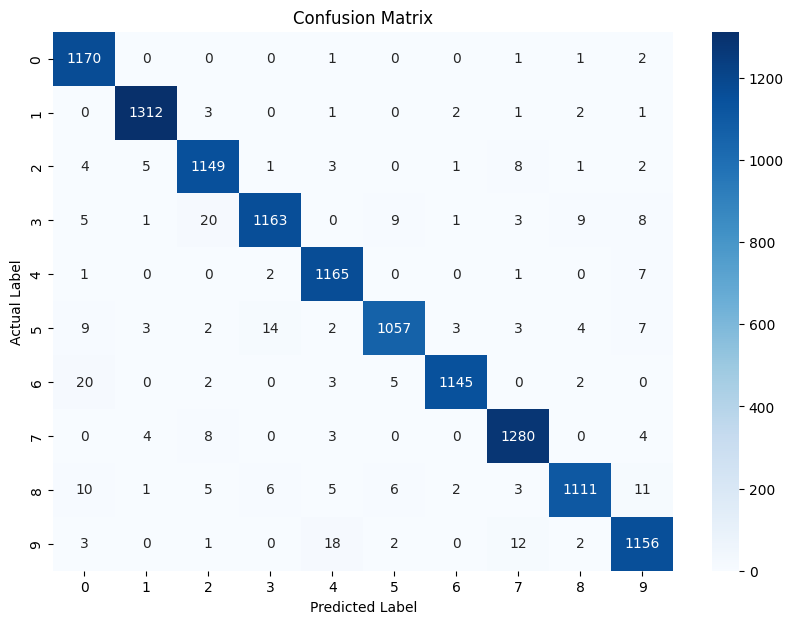


Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1175
           1       0.99      0.99      0.99      1322
           2       0.97      0.98      0.97      1174
           3       0.98      0.95      0.97      1219
           4       0.97      0.99      0.98      1176
           5       0.98      0.96      0.97      1104
           6       0.99      0.97      0.98      1177
           7       0.98      0.99      0.98      1299
           8       0.98      0.96      0.97      1160
           9       0.96      0.97      0.97      1194

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



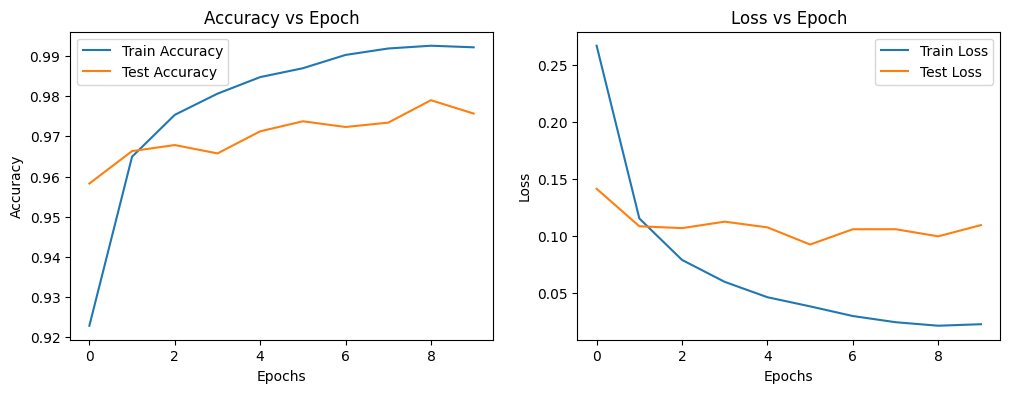

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Task 5: Conclusion

The Artificial Neural Network successfully classified MNIST handwritten digits, achieving high test accuracy with minimal misclassifications across all ten classes. The hidden layers in this model were crucial; they enabled the network to learn non-linear patterns and complex hierarchical representations from the raw pixel data, which simple linear models cannot achieve. A key advantage of Deep Learning over traditional Machine Learning demonstrated here is its ability to automatically extract relevant features directly from unstructured data, eliminating the need for manual feature engineering. However, standard ANNs have limitations in image processing tasks. Specifically, they lack spatial awareness because they require flattening the 2D image into a 1D vector, thereby losing the inherent structural relationships between adjacent pixels that architectures like Convolutional Neural Networks (CNNs) preserve. Overall, the model proved highly effective for this automated postal code recognition task.